# 時間序列(Time Series)預測 

## 載入相關套件 

In [1]:
import math
from typing import List, Tuple, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

## 判斷GPU是否存在

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入資料

In [3]:
df = pd.read_csv('nlp_data/airline-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.tail()

,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(-20.0, 0, '1959-05'),
  Text(0.0, 0, '1949-01'),
  Text(20.0, 0, '1950-09'),
  Text(40.0, 0, '1952-05'),
  Text(60.0, 0, '1954-01'),
  Text(80.0, 0, '1955-09'),
  Text(100.0, 0, '1957-05'),
  Text(120.0, 0, '1959-01'),
  Text(140.0, 0, '1960-09'),
  Text(160.0, 0, '')])

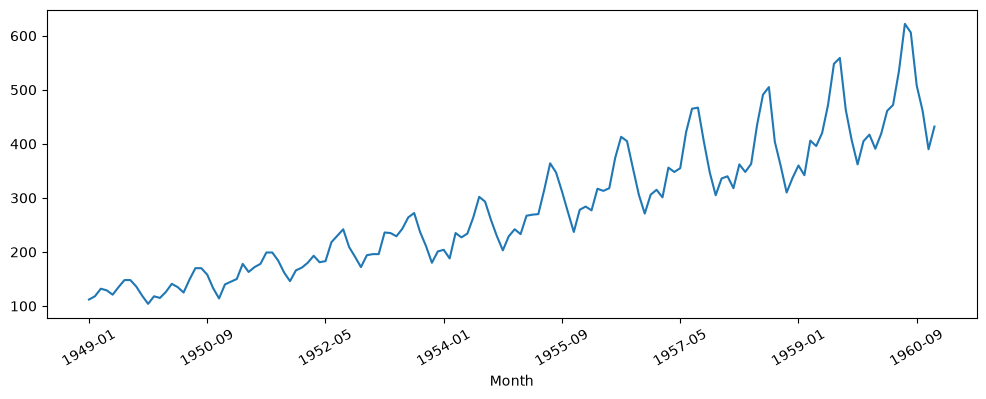

In [5]:
# 繪圖
df2 = df.set_index('Month')
df2.plot(legend=False, figsize=(12, 4))
plt.xticks(rotation=30)

In [6]:
len(df2)

144

In [7]:
look_back = 1  # 以前N期資料為 X，當期資料為 Y


# 函數：以前N期資料為 X，當前期資料為 Y
def create_dataset(data: np.ndarray, look_back: int) -> Tuple[torch.Tensor, torch.Tensor]:
    x: List[np.ndarray] = []
    y: List[np.ndarray] = []
    for i in range(len(data) - look_back - 1):
        _x = data[i : (i + look_back)]
        _y = data[i + look_back]
        x.append(_x)
        y.append(_y)

    return torch.Tensor(np.array(x)).to(device), torch.Tensor(np.array(y)).to(device)


dataset = df2[['Passengers']].values.astype('float32')

# X 常態化
scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)

# 資料分割
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train_data, test_data = dataset[0:train_size, :], dataset[train_size : len(dataset), :]

trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)
dataset.shape, trainY.shape

((144, 1), torch.Size([94, 1]))

In [8]:
dataset[-1]

array([0.6332046], dtype=float32)

In [9]:
trainX.shape, trainY.shape, testX.shape, testY.shape

(torch.Size([94, 1, 1]),
 torch.Size([94, 1]),
 torch.Size([46, 1, 1]),
 torch.Size([46, 1]))

In [10]:
torch.cat((trainX.reshape(trainX.shape[0], trainX.shape[1]), trainY), dim=1)

tensor([[0.0154, 0.0270],
        [0.0270, 0.0541],
        [0.0541, 0.0483],
        [0.0483, 0.0328],
        [0.0328, 0.0598],
        [0.0598, 0.0849],
        [0.0849, 0.0849],
        [0.0849, 0.0618],
        [0.0618, 0.0290],
        [0.0290, 0.0000],
        [0.0000, 0.0270],
        [0.0270, 0.0212],
        [0.0212, 0.0425],
        [0.0425, 0.0714],
        [0.0714, 0.0598],
        [0.0598, 0.0405],
        [0.0405, 0.0869],
        [0.0869, 0.1274],
        [0.1274, 0.1274],
        [0.1274, 0.1042],
        [0.1042, 0.0560],
        [0.0560, 0.0193],
        [0.0193, 0.0695],
        [0.0695, 0.0792],
        [0.0792, 0.0888],
        [0.0888, 0.1429],
        [0.1429, 0.1139],
        [0.1139, 0.1313],
        [0.1313, 0.1429],
        [0.1429, 0.1834],
        [0.1834, 0.1834],
        [0.1834, 0.1544],
        [0.1544, 0.1120],
        [0.1120, 0.0811],
        [0.0811, 0.1197],
        [0.1197, 0.1293],
        [0.1293, 0.1467],
        [0.1467, 0.1718],
        [0.1

## 建立模型

In [ ]:
class TimeSeriesModel(nn.Module):
    def __init__(self, hidden_size: int = 4, num_layers: int = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.LSTM(1, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(x.shape)
        # rnn_out, h_out = self.rnn(x)
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, (h_out, _) = self.rnn(x, (h_0, c_0))
        # print(h_out.shape)

        # 取最後一層的 h，並轉成二維
        h_out = cast(torch.Tensor, h_out)[-1].view(-1, self.hidden_size)
        return self.fc(h_out)


model = TimeSeriesModel(hidden_size=4, num_layers=1).to(device)

## 模型訓練

In [12]:
num_epochs = 2000
learning_rate = 0.01


def train(trainX: torch.Tensor, trainY: torch.Tensor):
    criterion = nn.MSELoss()  # MSE
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs: torch.Tensor = model(trainX)
        if epoch <= 0:
            print(outputs.shape)
        loss: torch.Tensor = criterion(outputs, trainY)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f"Epoch: {epoch}, loss: {loss.item():.5f}")


train(trainX, trainY)

torch.Size([94, 1])
Epoch: 0, loss: 0.06068
Epoch: 100, loss: 0.00220
Epoch: 200, loss: 0.00193
Epoch: 300, loss: 0.00192
Epoch: 400, loss: 0.00191
Epoch: 500, loss: 0.00190
Epoch: 600, loss: 0.00190
Epoch: 700, loss: 0.00190
Epoch: 800, loss: 0.00190
Epoch: 900, loss: 0.00190
Epoch: 1000, loss: 0.00190
Epoch: 1100, loss: 0.00190
Epoch: 1200, loss: 0.00190
Epoch: 1300, loss: 0.00190
Epoch: 1400, loss: 0.00190
Epoch: 1500, loss: 0.00190
Epoch: 1600, loss: 0.00190
Epoch: 1700, loss: 0.00190
Epoch: 1800, loss: 0.00190
Epoch: 1900, loss: 0.00190


## 模型評估

In [13]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()
trainPredict.shape

(94, 1)

In [14]:
trainY.shape, trainPredict.shape

(torch.Size([94, 1]), (94, 1))

In [15]:
# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(94, 1) (94, 1)
Train RMSE: 22.56
Test RMSE:  56.18


## 繪製實際資料和預測資料的圖表

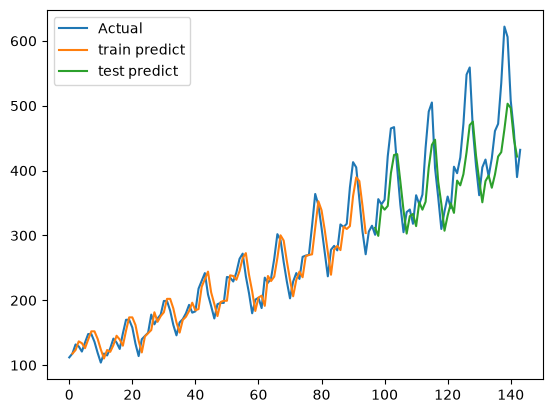

In [16]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : len(trainPredict) + look_back, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()

## 改變Loopback=3：X由前1期改為前3期 

In [ ]:
# 以前期資料為 X，當前期資料為 Y
look_back = 3
trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)

model = TimeSeriesModel(hidden_size=4, num_layers=1).to(device)
train(trainX, trainY)

torch.Size([92, 1])
Epoch: 0, loss: 0.12967
Epoch: 100, loss: 0.00357
Epoch: 200, loss: 0.00284
Epoch: 300, loss: 0.00203
Epoch: 400, loss: 0.00172
Epoch: 500, loss: 0.00168
Epoch: 600, loss: 0.00166
Epoch: 700, loss: 0.00160
Epoch: 800, loss: 0.00151
Epoch: 900, loss: 0.00149
Epoch: 1000, loss: 0.00147
Epoch: 1100, loss: 0.00146
Epoch: 1200, loss: 0.00145
Epoch: 1300, loss: 0.00143
Epoch: 1400, loss: 0.00142
Epoch: 1500, loss: 0.00140
Epoch: 1600, loss: 0.00138
Epoch: 1700, loss: 0.00137
Epoch: 1800, loss: 0.00136
Epoch: 1900, loss: 0.00136


In [18]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()

# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(92, 1) (92, 1)
Train RMSE: 19.01
Test RMSE:  57.21


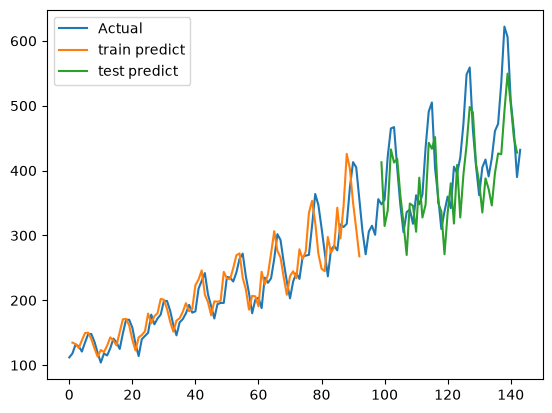

In [19]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : trainPredict.shape[0] + 1 :, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()

## Stacked LSTM

In [ ]:
# 以前期資料為 X，當前期資料為 Y
look_back = 3
trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)

model = TimeSeriesModel(hidden_size=4, num_layers=3).to(device)
train(trainX, trainY)

torch.Size([92, 1])
Epoch: 0, loss: 0.07302
Epoch: 100, loss: 0.00511
Epoch: 200, loss: 0.00185
Epoch: 300, loss: 0.00157
Epoch: 400, loss: 0.00152
Epoch: 500, loss: 0.00148
Epoch: 600, loss: 0.00141
Epoch: 700, loss: 0.00134
Epoch: 800, loss: 0.00130
Epoch: 900, loss: 0.00122
Epoch: 1000, loss: 0.00110
Epoch: 1100, loss: 0.00101
Epoch: 1200, loss: 0.00095
Epoch: 1300, loss: 0.00089
Epoch: 1400, loss: 0.00084
Epoch: 1500, loss: 0.00076
Epoch: 1600, loss: 0.00069
Epoch: 1700, loss: 0.00060
Epoch: 1800, loss: 0.00054
Epoch: 1900, loss: 0.00052


In [21]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()

# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(92, 1) (92, 1)
Train RMSE: 11.37
Test RMSE:  90.85


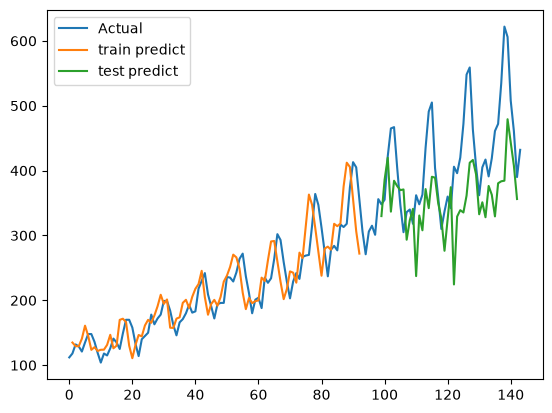

In [22]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : trainPredict.shape[0] + 1 :, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()